In [1]:
import pandas as pd

# Load cleaned dataset from Step 3
sales_long = pd.read_csv('../data/cleaned_sales.csv')
sales_long.head()


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN


Step 3: Feature Engineering
Why feature engineering matters:

ML models can’t “magically” know trends or seasonality.

Features give the model context: time patterns, past sales, price effects.

Without features like lags or rolling averages, the model would just guess.

Step 3.1: Time-based features

Features to create:

day_of_week → Helps model learn weekday patterns (e.g., weekends sell differently)

month → Captures monthly/seasonal trends

is_weekend → Binary 0/1 for weekend

is_holiday → Binary 0/1 if event_type_1 or event_type_2 is a holiday
Why:

Helps model predict spikes during weekends/holidays.

In [2]:
# Assume sales_long is your master dataset
import numpy as np

# Day of week already exists as 'weekday', convert to number if needed
sales_long['day_of_week'] = sales_long['wday']

# Month
sales_long['month'] = sales_long['month']

# Weekend flag (1 if Saturday or Sunday)
sales_long['is_weekend'] = sales_long['wday'].isin([1,7]).astype(int)

# Holiday flag (1 if event_type_1 or event_type_2 is not 'No Event')
sales_long['is_holiday'] = ((sales_long['event_type_1'] != 'No Event') | 
                            (sales_long['event_type_2'] != 'No Event')).astype(int)

sales_long[['date','day_of_week','month','is_weekend','is_holiday']].head()


,date,day_of_week,month,is_weekend,is_holiday
0,2011-01-29,1,1,1,0
1,2011-01-29,1,1,1,0
2,2011-01-29,1,1,1,0
3,2011-01-29,1,1,1,0
4,2011-01-29,1,1,1,0


Step 3.2: Lag features

Concept:

Past sales influence future sales.

Lags are just “sales from N days ago.”

Common lags: 7 days (1 week) or 28 days (1 month).
Why:

Allows the model to see trends from past days.

Lag 7 → weekly pattern

Lag 28 → monthly pattern

In [3]:
# Sort data for lagging
sales_long = sales_long.sort_values(['id','date'])

# Lag 7 and 28 days
sales_long['lag_7'] = sales_long.groupby('id')['sales'].shift(7)
sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)

sales_long[['id','date','sales','lag_7','lag_28']].head(10)


,id,date,sales,lag_7,lag_28
1612,FOODS_1_001_CA_1_validation,2011-01-29,3,NaN,NaN
32102,FOODS_1_001_CA_1_validation,2011-01-30,0,NaN,NaN
62592,FOODS_1_001_CA_1_validation,2011-01-31,0,NaN,NaN
93082,FOODS_1_001_CA_1_validation,2011-02-01,1,NaN,NaN
123572,FOODS_1_001_CA_1_validation,2011-02-02,4,NaN,NaN
154062,FOODS_1_001_CA_1_validation,2011-02-03,2,NaN,NaN
184552,FOODS_1_001_CA_1_validation,2011-02-04,0,NaN,NaN
215042,FOODS_1_001_CA_1_validation,2011-02-05,2,3.0,NaN
245532,FOODS_1_001_CA_1_validation,2011-02-06,0,0.0,NaN
276022,FOODS_1_001_CA_1_validation,2011-02-07,0,0.0,NaN


Step 3.3: Rolling / mean features

Concept:

Instead of one day, take an average over N days → smoother trend

Example: 7-day rolling mean
Why:

Captures smooth trends and volatility, which is especially useful for stores/products with irregular sales.

In [4]:
# 7-day rolling mean
sales_long['rolling_mean_7'] = sales_long.groupby('id')['sales'].transform(lambda x: x.shift(1).rolling(7).mean())

# 28-day rolling std
sales_long['rolling_std_28'] = sales_long.groupby('id')['sales'].transform(lambda x: x.shift(1).rolling(28).std())

sales_long[['id','date','sales','rolling_mean_7','rolling_std_28']].head(10)


,id,date,sales,rolling_mean_7,rolling_std_28
1612,FOODS_1_001_CA_1_validation,2011-01-29,3,NaN,NaN
32102,FOODS_1_001_CA_1_validation,2011-01-30,0,NaN,NaN
62592,FOODS_1_001_CA_1_validation,2011-01-31,0,NaN,NaN
93082,FOODS_1_001_CA_1_validation,2011-02-01,1,NaN,NaN
123572,FOODS_1_001_CA_1_validation,2011-02-02,4,NaN,NaN
154062,FOODS_1_001_CA_1_validation,2011-02-03,2,NaN,NaN
184552,FOODS_1_001_CA_1_validation,2011-02-04,0,NaN,NaN
215042,FOODS_1_001_CA_1_validation,2011-02-05,2,1.428571,NaN
245532,FOODS_1_001_CA_1_validation,2011-02-06,0,1.285714,NaN
276022,FOODS_1_001_CA_1_validation,2011-02-07,0,1.285714,NaN


Step 3.4: Price features

Concept:

Price changes affect demand.

We can calculate price lag and price change.
Why:

Helps model learn elasticity: if price goes up, demand may drop.

In [5]:
# Previous week price
sales_long['price_lag_7'] = sales_long.groupby('id')['sell_price'].shift(7)

# Price change (current - lag)
sales_long['price_change_7'] = sales_long['sell_price'] - sales_long['price_lag_7']

sales_long[['id','date','sell_price','price_lag_7','price_change_7']].head(10)


,id,date,sell_price,price_lag_7,price_change_7
1612,FOODS_1_001_CA_1_validation,2011-01-29,2.0,NaN,NaN
32102,FOODS_1_001_CA_1_validation,2011-01-30,2.0,NaN,NaN
62592,FOODS_1_001_CA_1_validation,2011-01-31,2.0,NaN,NaN
93082,FOODS_1_001_CA_1_validation,2011-02-01,2.0,NaN,NaN
123572,FOODS_1_001_CA_1_validation,2011-02-02,2.0,NaN,NaN
154062,FOODS_1_001_CA_1_validation,2011-02-03,2.0,NaN,NaN
184552,FOODS_1_001_CA_1_validation,2011-02-04,2.0,NaN,NaN
215042,FOODS_1_001_CA_1_validation,2011-02-05,2.0,2.0,0.0
245532,FOODS_1_001_CA_1_validation,2011-02-06,2.0,2.0,0.0
276022,FOODS_1_001_CA_1_validation,2011-02-07,2.0,2.0,0.0


| Feature                            | Type    | Why it matters         |
| ---------------------------------- | ------- | ---------------------- |
| day\_of\_week                      | Time    | Weekly sales pattern   |
| month                              | Time    | Seasonal trend         |
| is\_weekend                        | Binary  | Weekend spikes         |
| is\_holiday                        | Binary  | Holiday spikes         |
| lag\_7, lag\_28                    | Numeric | Past sales patterns    |
| rolling\_mean\_7, rolling\_std\_28 | Numeric | Trend + volatility     |
| price\_lag\_7, price\_change\_7    | Numeric | Price effect on demand |


Step 4: Splitting Data
Why we split data this way

Time series data is sequential → we cannot randomly shuffle rows.

Use chronological split:

Train → earlier data (learn patterns)

Validation → last few weeks before test (tune hyperparameters)

Test → last few weeks (evaluate final performance)

Common split in M5:

Train → all days except last 28 for validation

Validation → last 28 days before test

Test → last 28 days

In [6]:
#Step 4.1: Convert date column
sales_long['date'] = pd.to_datetime(sales_long['date'])


Explanation:

max_date = last day in dataset.

Validation starts 28 days before the last date → ensures validation covers recent period.

In [7]:
# Latest date in the dataset
max_date = sales_long['date'].max()
print("Latest date:", max_date)

# Validation set = last 28 days
valid_start = max_date - pd.Timedelta(days=27)  # inclusive of last day
print("Validation starts:", valid_start)


Latest date: 2016-04-24 00:00:00
Validation starts: 2016-03-28 00:00:00


Step 4.3: Split dataset
Explanation:

Train = model learns patterns from historical data.

Validation = check performance on recent unseen data.

In [8]:
# Train: all dates before validation
train = sales_long[sales_long['date'] < valid_start]

# Validation: last 28 days
valid = sales_long[(sales_long['date'] >= valid_start) & (sales_long['date'] <= max_date)]


#Step 4.4: Select features & target
Explanation:

X = features (inputs)

y = target (sales to predict)

Check shapes to make sure splits are correct.

In [9]:
# Features to use in XGBoost
feature_cols = ['day_of_week', 'month', 'is_weekend', 'is_holiday',
                'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_std_28',
                'sell_price', 'price_lag_7', 'price_change_7']

# Train set
X_train = train[feature_cols]
y_train = train['sales']

# Validation set
X_valid = valid[feature_cols]
y_valid = valid['sales']

# Quick check shapes
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)


X_train shape: (57473650, 11)
X_valid shape: (853720, 11)


Step 4.5: Handle missing lag/rolling values
Why:

First few days of lags/rolling features are NaN because there’s not enough history.

Filling with 0 ensures XGBoost can train without errors.

In [10]:
# Fill missing lag/rolling values with 0
X_train = X_train.fillna(0)
X_valid = X_valid.fillna(0)


Step 5: XGBoost Modeling

In [11]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Step 5.2: Create DMatrix (optional, faster for XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)


Why:

DMatrix is XGBoost’s optimized data structure.

Speeds up training and reduces memory usage.

In [12]:
#Step 5.3: Set XGBoost parameters
params = {
    'objective': 'reg:squarederror',  # Regression problem
    'eval_metric': 'rmse',            # Root Mean Squared Error
    'learning_rate': 0.05,            # Step size shrinkage
    'max_depth': 6,                    # Max tree depth
    'subsample': 0.8,                  # Random subsample rows for each tree
    'colsample_bytree': 0.8,           # Random subset of features
    'n_estimators': 500,               # Number of boosting rounds
    'random_state': 42
}


Why:

learning_rate → smaller = more stable training

max_depth → controls overfitting

subsample & colsample_bytree → regularization

n_estimators → number of trees to fit

Step 5.4: Train the model
Why:

early_stopping_rounds → stops training if validation RMSE does not improve for 20 rounds (prevents overfitting).

eval_set → monitors performance on validation set.

In [13]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'rmse',
    'seed': 42
}

evallist = [(dtrain, 'train'), (dvalid, 'eval')]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evallist,
    early_stopping_rounds=20
)



[0]	train-rmse:3.75520	eval-rmse:3.48037
[1]	train-rmse:3.64175	eval-rmse:3.36609
[2]	train-rmse:3.53707	eval-rmse:3.26051
[3]	train-rmse:3.44800	eval-rmse:3.16950
[4]	train-rmse:3.35560	eval-rmse:3.07512
[5]	train-rmse:3.27022	eval-rmse:2.98826
[6]	train-rmse:3.18996	eval-rmse:2.90674
[7]	train-rmse:3.11569	eval-rmse:2.83103
[8]	train-rmse:3.05625	eval-rmse:2.76980
[9]	train-rmse:2.99220	eval-rmse:2.70456
[10]	train-rmse:2.93417	eval-rmse:2.64615
[11]	train-rmse:2.88027	eval-rmse:2.59157
[12]	train-rmse:2.83001	eval-rmse:2.54046
[13]	train-rmse:2.78467	eval-rmse:2.49506
[14]	train-rmse:2.74251	eval-rmse:2.45272
[15]	train-rmse:2.70375	eval-rmse:2.41364
[16]	train-rmse:2.66875	eval-rmse:2.37880
[17]	train-rmse:2.63827	eval-rmse:2.34874
[18]	train-rmse:2.61209	eval-rmse:2.32226
[19]	train-rmse:2.58509	eval-rmse:2.29432
[20]	train-rmse:2.56263	eval-rmse:2.27192
[21]	train-rmse:2.53854	eval-rmse:2.24861
[22]	train-rmse:2.51697	eval-rmse:2.22706
[23]	train-rmse:2.49663	eval-rmse:2.20768
[2

In [14]:
# Predict on validation set
y_pred = bst.predict(dvalid)
print(y_pred[:10])


[0.71913284 0.76606655 0.76212233 0.6296974  0.68647045 1.3544487
 1.1231408  0.89017534 1.020448   1.00653   ]


Each number is the model’s predicted sales for a specific product on a specific day in your validation set.

They are floats because regression models output continuous values.

Example: 0.71913284 → the model predicts about 0.72 units sold.

Actual sales may be integers (0, 1, 2, …), so you can round if needed when comparing.

In [15]:
# Evaluate RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 2.0182716676892554


RMSE = 2.018 → on average, the predicted value is about 2 units away from the actual sales.

So even though some predictions are <1, if the actual sales were 2–3 units, the RMSE is reasonable.

In [16]:
y_pred_rounded = np.round(y_pred)


In [17]:
for actual, pred in zip(y_valid.values[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {pred:.2f}")


Actual: 2, Predicted: 0.72
Actual: 1, Predicted: 0.77
Actual: 1, Predicted: 0.76
Actual: 0, Predicted: 0.63
Actual: 4, Predicted: 0.69
Actual: 0, Predicted: 1.35
Actual: 0, Predicted: 1.12
Actual: 4, Predicted: 0.89
Actual: 1, Predicted: 1.02
Actual: 3, Predicted: 1.01


Hyperparameter tuning can significantly improve your XGBoost model by finding the best combination of parameters for your dataset
| Parameter          | What it does                                    | Typical range |
| ------------------ | ----------------------------------------------- | ------------- |
| `n_estimators`     | Number of boosting rounds (trees)               | 100–1000      |
| `max_depth`        | Max depth of each tree                          | 3–10          |
| `learning_rate`    | Step size for updates                           | 0.01–0.3      |
| `subsample`        | Fraction of rows used per tree                  | 0.5–1         |
| `colsample_bytree` | Fraction of features per tree                   | 0.5–1         |
| `min_child_weight` | Minimum sum of instance weight needed in a leaf | 1–10          |
| `gamma`            | Minimum loss reduction to make a split          | 0–5           |
| `reg_alpha`        | L1 regularization                               | 0–1           |
| `reg_lambda`       | L2 regularization                               | 0–1           |

Tuning these can reduce overfitting and improve predictions.
We use :
Random Search → samples random combinations → faster, good for large datasets.

In [22]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
import matplotlib.pyplot as plt
import numpy as np
import pickle

# -----------------------------
# 5.1 Pick subset of products (from long-format sales data)
# -----------------------------
subset_ids = sales_long['id'].unique()[:50]   # first 50 product IDs
sales_sub = sales_long[sales_long['id'].isin(subset_ids)]

# Split into train/valid for subset
train_sub = sales_sub[sales_sub['date'] < valid_start]
valid_sub = sales_sub[(sales_sub['date'] >= valid_start) & (sales_sub['date'] <= max_date)]

# Features/target for subset
X_train_sub = train_sub.drop(columns=['sales'])
y_train_sub = train_sub['sales']

X_valid_sub = valid_sub.drop(columns=['sales'])
y_valid_sub = valid_sub['sales']

print("Subset train shape:", X_train_sub.shape)
print("Subset valid shape:", X_valid_sub.shape)

Subset train shape: (94250, 30)
Subset valid shape: (1400, 30)


In [24]:
# Drop columns not useful for model
drop_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date']
X_train_sub_enc = X_train_sub.drop(columns=[c for c in drop_cols if c in X_train_sub.columns])
X_valid_sub_enc = X_valid_sub.drop(columns=[c for c in drop_cols if c in X_valid_sub.columns])

# Do the same for full dataset later
X_train_enc = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_valid_enc = X_valid.drop(columns=[c for c in drop_cols if c in X_valid.columns])


In [28]:
print("Train subset dtypes:\n", X_train_sub_enc.dtypes)
print("Any NaNs in train?", X_train_sub_enc.isna().sum().sum())
print("Shapes:", X_train_sub_enc.shape, y_train_sub.shape)


Train subset dtypes:
 d                  object
wm_yr_wk            int64
weekday            object
wday                int64
month               int64
year                int64
event_name_1       object
event_type_1       object
event_name_2       object
event_type_2       object
snap_CA             int64
snap_TX             int64
snap_WI             int64
sell_price        float64
day_of_week         int64
is_weekend          int64
is_holiday          int64
lag_7             float64
lag_28            float64
rolling_mean_7    float64
rolling_std_28    float64
price_lag_7       float64
price_change_7    float64
dtype: object
Any NaNs in train? 0
Shapes: (94250, 23) (94250,)


In [30]:
from sklearn.preprocessing import LabelEncoder

# Make copies
X_train_sub_enc = X_train_sub.copy()
X_valid_sub_enc = X_valid_sub.copy()

# Categorical columns
cat_cols = ['d', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

# Encode using union of train+valid values
for col in cat_cols:
    if col in X_train_sub_enc.columns:
        le = LabelEncoder()
        le.fit(list(X_train_sub_enc[col].astype(str)) + list(X_valid_sub_enc[col].astype(str)))
        X_train_sub_enc[col] = le.transform(X_train_sub_enc[col].astype(str))
        X_valid_sub_enc[col] = le.transform(X_valid_sub_enc[col].astype(str))

print("Encoded dtypes:\n", X_train_sub_enc.dtypes)


Encoded dtypes:
 id                        object
item_id                   object
dept_id                   object
cat_id                    object
store_id                  object
state_id                  object
d                          int64
date              datetime64[ns]
wm_yr_wk                   int64
weekday                    int64
wday                       int64
month                      int64
year                       int64
event_name_1               int64
event_type_1               int64
event_name_2               int64
event_type_2               int64
snap_CA                    int64
snap_TX                    int64
snap_WI                    int64
sell_price               float64
day_of_week                int64
is_weekend                 int64
is_holiday                 int64
lag_7                    float64
lag_28                   float64
rolling_mean_7           float64
rolling_std_28           float64
price_lag_7              float64
price_change_7           f

In [45]:
# -----------------------------
# Step 5: Hyperparameter tuning with Label Encoding
# -----------------------------
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import numpy as np

# -----------------------------
# 5.1 Prepare copies of train/validation
# -----------------------------
X_train_sub_enc = X_train_sub.copy()
X_valid_sub_enc = X_valid_sub.copy()

# -----------------------------
# 5.2 Drop invalid object/datetime columns for XGBoost
# -----------------------------
cols_to_drop = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date']
X_train_sub_enc = X_train_sub_enc.drop(columns=cols_to_drop)
X_valid_sub_enc = X_valid_sub_enc.drop(columns=cols_to_drop)

# -----------------------------
# 5.3 Encode categorical columns
# -----------------------------
cat_cols = ['d', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in cat_cols:
    if col in X_train_sub_enc.columns:
        le = LabelEncoder()
        le.fit(list(X_train_sub_enc[col].astype(str)) + list(X_valid_sub_enc[col].astype(str)))
        X_train_sub_enc[col] = le.transform(X_train_sub_enc[col].astype(str))
        X_valid_sub_enc[col] = le.transform(X_valid_sub_enc[col].astype(str))

print("Encoded train subset shape:", X_train_sub_enc.shape)

# -----------------------------
# 5.4 Fill NaNs in numeric columns
# -----------------------------
numeric_cols_with_nan = ['sell_price', 'lag_7', 'lag_28',
                         'rolling_mean_7', 'rolling_std_28',
                         'price_lag_7', 'price_change_7']

for col in numeric_cols_with_nan:
    median_val = X_train_sub_enc[col].median()
    X_train_sub_enc[col] = X_train_sub_enc[col].fillna(median_val)
    X_valid_sub_enc[col] = X_valid_sub_enc[col].fillna(median_val)

# -----------------------------
# 5.5 Ensure target is 1D
# -----------------------------
y_train_sub = np.array(y_train_sub).ravel()

# -----------------------------
# 5.6 Define XGB model and parameter grid
# -----------------------------
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    n_jobs=1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1]
}

# -----------------------------
# 5.7 RandomizedSearchCV with built-in RMSE scorer
# -----------------------------
rs = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_root_mean_squared_error',  # built-in RMSE
    cv=3,
    verbose=2,
    random_state=42
)

# -----------------------------
# 5.8 Fit model
# -----------------------------
rs.fit(X_train_sub_enc, y_train_sub)

print("Best parameters found:", rs.best_params_)
print("Best CV score (negative RMSE):", rs.best_score_)


Encoded train subset shape: (94250, 23)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.7; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.7; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.7; total time=   0.8s
[CV] END colsample_bytree=0.7, gamm

[0]	validation_0-rmse:4.54472	validation_1-rmse:1.98415
[10]	validation_0-rmse:3.53639	validation_1-rmse:1.61242
[20]	validation_0-rmse:3.05382	validation_1-rmse:1.44338
[30]	validation_0-rmse:2.84609	validation_1-rmse:1.37732
[40]	validation_0-rmse:2.75224	validation_1-rmse:1.34875
[50]	validation_0-rmse:2.70023	validation_1-rmse:1.33804
[60]	validation_0-rmse:2.66986	validation_1-rmse:1.33669
[70]	validation_0-rmse:2.64822	validation_1-rmse:1.33609
[80]	validation_0-rmse:2.63190	validation_1-rmse:1.33494
[90]	validation_0-rmse:2.62117	validation_1-rmse:1.33357
[100]	validation_0-rmse:2.61046	validation_1-rmse:1.33299
[110]	validation_0-rmse:2.60126	validation_1-rmse:1.33239
[120]	validation_0-rmse:2.59285	validation_1-rmse:1.33168
[130]	validation_0-rmse:2.58441	validation_1-rmse:1.33130
[140]	validation_0-rmse:2.57594	validation_1-rmse:1.33074
[150]	validation_0-rmse:2.56799	validation_1-rmse:1.33069
[160]	validation_0-rmse:2.56068	validation_1-rmse:1.32623
[170]	validation_0-rmse:2

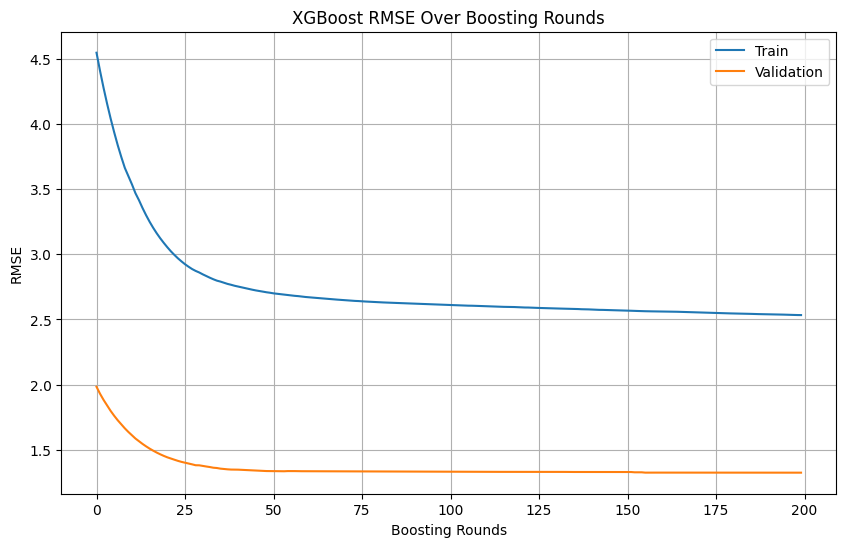

Validation RMSE: 1.3257304877036344
Model saved to final_xgb_model.pkl


In [51]:
# -----------------------------
# Step 6: Final model training with evaluation tracking
# -----------------------------
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Best parameters from RandomizedSearchCV
best_params = {
    'subsample': 0.8,
    'n_estimators': 200,
    'min_child_weight': 3,
    'max_depth': 4,
    'learning_rate': 0.05,
    'gamma': 0,
    'colsample_bytree': 0.7,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',   # <-- set here
    'random_state': 42,
    'n_jobs': -1
}

# Initialize final XGBRegressor
final_model = xgb.XGBRegressor(**best_params)

# Fit model with eval set for tracking
final_model.fit(
    X_train_sub_enc,
    y_train_sub,
    eval_set=[(X_train_sub_enc, y_train_sub), (X_valid_sub_enc, y_valid_sub)],
    verbose=10
)

# -----------------------------
# Step 7: Plot training vs validation RMSE
# -----------------------------
results = final_model.evals_result()

epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.figure(figsize=(10,6))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('XGBoost RMSE Over Boosting Rounds')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Step 8: Evaluate on validation set
# -----------------------------
y_pred = final_model.predict(X_valid_sub_enc)
rmse_val = np.sqrt(mean_squared_error(y_valid_sub, y_pred))
print("Validation RMSE:", rmse_val)

# -----------------------------
# Step 9: Save model
# -----------------------------
with open('final_xgb_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Model saved to final_xgb_model.pkl")


In [52]:
# Instead of pickle
final_model.save_model("final_xgb_model.json")


In [53]:
# List all feature columns
print(X_train_sub_enc.columns.tolist())

# Or just see the first few rows with column names
print(X_train_sub_enc.head())


['d', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day_of_week', 'is_weekend', 'is_holiday', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_std_28', 'price_lag_7', 'price_change_7']
           d  wm_yr_wk  weekday  wday  month  year  event_name_1  \
1612       0     11101        2     1      1  2011            19   
32102   1025     11101        3     2      1  2011            19   
62592   1136     11101        1     3      1  2011            19   
93082   1247     11101        5     4      2  2011            19   
123572  1358     11101        6     5      2  2011            19   

        event_type_1  event_name_2  event_type_2  ...  sell_price  \
1612               2             3             1  ...         2.0   
32102              2             3             1  ...         2.0   
62592              2             3             1  ...         2.0   
93082              